In [ ]:
!pip install osmnx geopandas shapely lightgbm xgboost catboost contextily mapclassify

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.5 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

from shapely.geometry import box
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.neighbors import BallTree

In [ ]:
# Задание 1. Загрузка графа дорожной сети.

bbox = (30.18, 59.86, 30.55, 60.03)
polygon_wgs = box(*bbox)

G = ox.graph_from_polygon(
    polygon_wgs,           # polygon_wgs
    network_type="drive",  # тип сети
    simplify=True,
    retain_all=False
)

# Получаем GeoDataFrame узлов и рёбер
nodes, edges = ox.graph_to_gdfs(G, nodes=True, edges=True)
edges = edges.reset_index()
nodes = nodes.reset_index()

print(edges.shape)
edges.head()

(16176, 18)


,u,v,key,osmid,highway,lanes,maxspeed,oneway,reversed,length,name,geometry,bridge,junction,ref,width,tunnel,access
0,219808,2327840,0,33997807,primary_link,2,RU:urban,False,False,26.026139,NaN,"LINESTRING (30.33142 59.89509, 30.33109 59.89526)",NaN,NaN,NaN,NaN,NaN,NaN
1,219808,389449562,0,201380605,primary,3,RU:urban,True,False,31.504625,Лиговский проспект,"LINESTRING (30.33142 59.89509, 30.33182 59.89529)",NaN,NaN,NaN,NaN,NaN,NaN
2,219811,1832085962,0,33997784,primary_link,2,RU:urban,False,False,27.905147,NaN,"LINESTRING (30.33748 59.8993, 30.33793 59.8992)",NaN,NaN,NaN,NaN,NaN,NaN
3,219811,1465050831,0,"[1123339577, 178581714]",primary,3,RU:urban,True,False,394.654005,Лиговский проспект,"LINESTRING (30.33748 59.8993, 30.3372 59.89897...",NaN,NaN,NaN,NaN,NaN,NaN
4,219812,249890545,0,4459876,primary,2,RU:urban,True,False,33.758153,Воздухоплавательная улица,"LINESTRING (30.33955 59.90173, 30.33982 59.90146)",NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Задание 2. Перевод в метрическую CRS.

# Проверяем что исходные данные в WGS84
assert edges.crs.to_epsg() == 4326, f"Ожидался EPSG:4326, получен {edges.crs}"

edges_m = edges.to_crs("EPSG:32636")

print(edges_m.crs)


EPSG:32636


In [ ]:
# Задание 3. Геометрические признаки.

roads = edges_m.copy()

# Длина сегмента в метрах
roads["length_m_geom"] = roads.geometry.length

# Центроид сегмента
roads["centroid_x"] = roads.geometry.centroid.x
roads["centroid_y"] = roads.geometry.centroid.y

# Прямое расстояние между началом и концом LineString
def straight_distance(geom):
    coords = list(geom.coords)
    x1, y1 = coords[0]
    x2, y2 = coords[-1]
    return np.sqrt((x2 - x1)**2 + (y2 - y1)**2)  # евклидово расстояние

roads["straight_dist_m"] = roads.geometry.apply(straight_distance)

# Извилистость
roads["sinuosity"] = roads["length_m_geom"] / roads["straight_dist_m"].replace(0, np.nan)
roads["sinuosity"] = roads["sinuosity"].replace([np.inf, -np.inf], np.nan).fillna(1)

# Направление дороги в радианах
def segment_angle(geom):
    coords = list(geom.coords)
    x1, y1 = coords[0]
    x2, y2 = coords[-1]
    dx = x2 - x1
    dy = y2 - y1
    return np.arctan2(dy, dx)

roads["angle_rad"] = roads.geometry.apply(segment_angle)
roads[["length_m_geom", "straight_dist_m", "sinuosity", "angle_rad"]].describe()

,length_m_geom,straight_dist_m,sinuosity,angle_rad
count,16176.000000,16176.000000,16176.000000,16176.000000
mean,183.554633,177.120246,1.045379,0.001167
std,243.995907,228.388397,0.896788,1.818570
min,1.236514,0.000000,1.000000,-3.141433
25%,28.296945,27.432919,1.000000,-1.582503
50%,106.825070,104.682539,1.000018,-0.000176
75%,248.837794,243.176946,1.002707,1.554398
max,6640.370574,5357.940848,76.797540,3.140873


In [ ]:
# Задание 4. Унитарное кодирование для highway.

roads["highway_str"] = roads["highway"].apply(
    lambda x: ",".join(x) if isinstance(x, list) else str(x)
)

highway_dummies = pd.get_dummies(roads["highway_str"], prefix="highway")
roads = pd.concat([roads, highway_dummies], axis=1)
highway_dummies.head()

,highway_living_street,"highway_living_street,residential",highway_motorway,highway_primary,highway_primary_link,"highway_primary_link,primary","highway_primary_link,residential",highway_residential,highway_secondary,"highway_secondary,secondary_link",highway_secondary_link,highway_tertiary,"highway_tertiary,residential",highway_tertiary_link,highway_tetriary,highway_trunk,highway_unclassified,"highway_unclassified,living_street","highway_unclassified,residential","highway_unclassified,tertiary"
0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Задание 5. Загрузка POI и остановок.

poi_tags = {
    "amenity": True,
    "shop": True,
    "office": True,
    "tourism": True,
    "leisure": True,
}

stop_tags = {
    "highway": "bus_stop",
    "public_transport": True,
    "railway": ["station", "subway_entrance", "tram_stop"]
}

pois  = ox.features_from_polygon(polygon_wgs, tags=poi_tags)
stops = ox.features_from_polygon(polygon_wgs, tags=stop_tags)

print("POI:", pois.shape)
print("Stops:", stops.shape)

POI: (96942, 1227)
Stops: (7435, 124)


In [ ]:
# Задание 6. Перевод в метрическую CRS и центроиды.

def to_points(gdf, crs_target):
    gdf = gdf.copy()
    gdf = gdf.to_crs(crs_target)
    gdf["geometry"] = gdf.geometry.representative_point()
    return gdf

pois_m  = to_points(pois,  roads.crs)
stops_m = to_points(stops, roads.crs)

pois_m  = pois_m[~pois_m.geometry.is_empty  & pois_m.geometry.notna()]
stops_m = stops_m[~stops_m.geometry.is_empty & stops_m.geometry.notna()]

pois_m.head()

geometry         amenity  \
element id                                                          
node    29001764   POINT (346911.245 6645602.235)  ferry_terminal   
        248465159  POINT (355699.365 6655570.419)             NaN   
        248465166  POINT (355735.863 6655631.331)             NaN   
        248701411   POINT (354243.62 6655104.647)             NaN   
        249082841  POINT (349260.755 6647401.446)             NaN   

                          railway        contact:email  \
element id                                               
node    29001764   ferry_terminal                  NaN   
        248465159             NaN  fclub-spb@yandex.ru   
        248465166             NaN                  NaN   
        248701411             NaN                  NaN   
        249082841             NaN                  NaN   

                                   contact:phone       contact:website  \
element id                                                               
node    29001764                             NaN                   NaN   
        248465159  +7 812 2918980;+7 812 5908868  https://fclub-spb.ru   
        248465166                            NaN                   NaN   
        248701411                            NaN                   NaN   
        249082841                            NaN                   NaN   

                         leisure            name  \
element id                                         
node    29001764             NaN             NaN   
        248465159  sports_centre          Фитнес   
        248465166            NaN    Всё для дома   
        248701411            NaN             NaN   
        249082841            NaN  Петру Великому   

                                          opening_hours        shop  ...  \
element id                                                           ...   
node    29001764                                    NaN         NaN  ...   
        248465159  Mo-Fr 07:00-23:00; Sa-Su 09:00-22:00         NaN  ...   
        248465166                                   NaN         yes  ...   
        248701411                                   NaN  car_repair  ...   
        249082841                                   NaN         NaN  ...   

                  brand:wikipedia:ar brand:short canoe:type  \
element id                                                    
node    29001764                 NaN         NaN        NaN   
        248465159                NaN         NaN        NaN   
        248465166                NaN         NaN        NaN   
        248701411                NaN         NaN        NaN   
        249082841                NaN         NaN        NaN   

                  education_programme:FR ref:en ref:ru addr:housenumber2  \
element id                                                                 
node    29001764                     NaN    NaN    NaN               NaN   
        248465159                    NaN    NaN    NaN               NaN   
        248465166                    NaN    NaN    NaN               NaN   
        248701411                    NaN    NaN    NaN               NaN   
        249082841                    NaN    NaN    NaN               NaN   

                  blood:plasma blood:whole donation:compensation  
element id                                                        
node    29001764           NaN         NaN                   NaN  
        248465159          NaN         NaN                   NaN  
        248465166          NaN         NaN                   NaN  
        248701411          NaN         NaN                   NaN  
        249082841          NaN         NaN                   NaN  

[5 rows x 1227 columns]

In [ ]:
# Задание 7. Пространственные признаки через BallTree.

def nearest_and_count(source_gdf, target_gdf, radius=300):
    source_coords = np.vstack([
        source_gdf.geometry.centroid.x,
        source_gdf.geometry.centroid.y
    ]).T

    target_coords = np.vstack([
        target_gdf.geometry.x,
        target_gdf.geometry.y
    ]).T

    tree = BallTree(target_coords, metric="euclidean")

    # Расстояние до ближайшего объекта
    dist, ind = tree.query(source_coords, k=1)
    nearest_dist = dist[:, 0]

    # Количество объектов в радиусе
    counts = tree.query_radius(source_coords, r=radius, count_only=True)

    return nearest_dist, counts

# Для расчётов используем центроиды дорог как точки
road_points = roads.copy()
road_points["geometry"] = road_points.geometry.centroid

roads["dist_to_poi_m"],  roads["poi_count_300m"]  = nearest_and_count(road_points, pois_m,  radius=300)
roads["dist_to_stop_m"], roads["stop_count_300m"] = nearest_and_count(road_points, stops_m, radius=300)

roads[["dist_to_poi_m", "poi_count_300m", "dist_to_stop_m", "stop_count_300m"]].describe()

,dist_to_poi_m,poi_count_300m,dist_to_stop_m,stop_count_300m
count,16176.000000,16176.000000,16176.000000,16176.000000
mean,49.583569,140.513229,143.417061,9.910423
std,57.391652,133.199795,145.281730,7.527159
min,0.293001,0.000000,0.160834,0.000000
25%,20.350445,47.000000,48.666572,4.000000
50%,34.839845,96.000000,103.713260,8.000000
75%,58.375453,197.000000,191.644245,14.000000
max,1095.915800,1003.000000,1695.642643,56.000000


In [ ]:
# Задание 8. Графовые признаки (степень узлов).

roads = roads.reset_index(drop=True)

# Словарь степеней узлов
node_degree = dict(G.degree())

roads["u_degree"] = roads["u"].map(node_degree)
roads["v_degree"] = roads["v"].map(node_degree)
roads["mean_node_degree"] = (roads["u_degree"] + roads["v_degree"]) / 2

roads[["u_degree", "v_degree", "mean_node_degree"]].describe()

,u_degree,v_degree,mean_node_degree
count,16176.000000,16176.000000,16176.000000
mean,4.424641,4.423405,4.424023
std,1.320487,1.322241,1.082633
min,1.000000,1.000000,1.500000
25%,3.000000,3.000000,3.500000
50%,4.000000,4.000000,4.000000
75%,6.000000,6.000000,5.000000
max,10.000000,10.000000,8.500000


In [ ]:
# Задание 9. Формирование целевой переменной.

def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

roads["length_norm"]    = minmax(roads["length_m_geom"].clip(upper=roads["length_m_geom"].quantile(0.99)))
roads["poi_count_norm"] = minmax(roads["poi_count_300m"])
roads["stop_count_norm"]= minmax(roads["stop_count_300m"])
roads["degree_norm"]    = minmax(roads["mean_node_degree"])
roads["near_poi_norm"]  = 1 - minmax(roads["dist_to_poi_m"].clip(upper=roads["dist_to_poi_m"].quantile(0.99)))
roads["near_stop_norm"] = 1 - minmax(roads["dist_to_stop_m"].clip(upper=roads["dist_to_stop_m"].quantile(0.99)))

rng = np.random.default_rng(42)
noise = rng.normal(0, 0.05, size=len(roads))  # шум имитирует случайные факторы (погода, время суток)

roads["traffic_load_score"] = (
    0.20 * roads["length_norm"]    +
    0.15 * roads["poi_count_norm"] +
    0.15 * roads["stop_count_norm"]+
    0.20 * roads["degree_norm"]    +
    0.15 * roads["near_poi_norm"]  +
    0.15 * roads["near_stop_norm"] +
    noise
)

roads["traffic_load_score"] = roads["traffic_load_score"].clip(0, 1)
roads["traffic_load_score"].describe()

,traffic_load_score
count,16176.000000
mean,0.413266
std,0.090003
min,0.000000
25%,0.357490
50%,0.415885
75%,0.472287
max,0.814876


In [ ]:
# Задание 10. Подготовка признаков для модели.

def clean_feature_names(df):
    df.columns = (
        df.columns
        .str.replace(r'[^A-Za-z0-9_]', '_', regex=True)
        .str.replace(r'_+', '_', regex=True)
        .str.strip('_')
    )
    return df

roads = clean_feature_names(roads)

base_features = [
    "length_m_geom",
    "straight_dist_m",
    "sinuosity",
    "angle_rad",
    "centroid_x",
    "centroid_y",
    "dist_to_poi_m",
    "poi_count_300m",
    "dist_to_stop_m",
    "stop_count_300m",
    "mean_node_degree",
]

highway_features = [c for c in roads.columns
                    if c.startswith("highway_") and c != "highway_str"]
feature_cols = base_features + highway_features

X = roads[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = roads["traffic_load_score"]

print(X.shape, y.shape)

(16176, 31) (16176,)


In [ ]:
# Задание 11. Разделение на train/test.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(X_train.shape, X_test.shape)

(12132, 31) (4044, 31)


In [ ]:
# Задание 12–13. Обучение GBDT-моделей и метрики.

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# LightGBM
lgbm = LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)

mae_lgbm  = mean_absolute_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))

# XGBoost
xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

# CatBoost
cat = CatBoostRegressor(iterations=300, learning_rate=0.05, random_state=42, verbose=0)
cat.fit(X_train, y_train)
y_pred_cat = cat.predict(X_test)

mae_cat  = mean_absolute_error(y_test, y_pred_cat)
rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))

print("=" * 50)
print(f"{'Модель':<12} {'MAE':>10} {'RMSE':>10}")
print("=" * 50)
print(f"{'LightGBM':<12} {mae_lgbm:>10.4f} {rmse_lgbm:>10.4f}")
print(f"{'XGBoost':<12} {mae_xgb:>10.4f} {rmse_xgb:>10.4f}")
print(f"{'CatBoost':<12} {mae_cat:>10.4f} {rmse_cat:>10.4f}")
print("=" * 50)

Модель              MAE       RMSE
LightGBM         0.0403     0.0507
XGBoost          0.0408     0.0512
CatBoost         0.0396     0.0498


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Лучшие параметры: {'learning_rate': 0.03, 'min_child_samples': 10, 'n_estimators': 200, 'num_leaves': 31}
Лучшая модель — MAE: 0.0400, RMSE: 0.0503


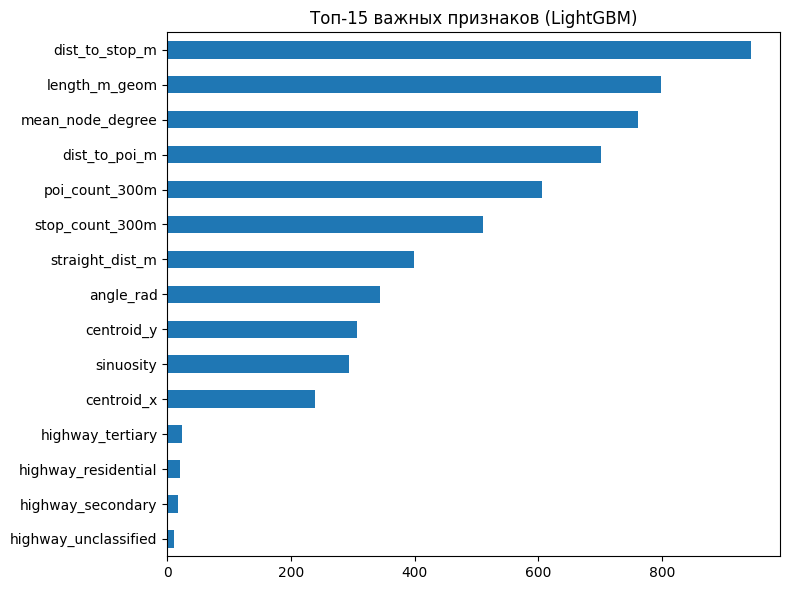

In [ ]:
# Задание 14. Подбор гиперпараметров для лучшей модели.
# Выбираем лучшую модель как baseline

from sklearn.model_selection import GridSearchCV

# n_estimators: 200–400 — достаточно для данного размера выборки
# learning_rate: 0.03–0.1 — стандартный диапазон для GBDT
# num_leaves: 31 (по умолчанию) и 63 — контролируют сложность дерева
# min_child_samples: 10–20 — защита от переобучения на малых листьях
param_grid = {
    "n_estimators":  [200, 400],
    "learning_rate": [0.03, 0.05, 0.1],
    "num_leaves":    [31, 63],
    "min_child_samples": [10, 20],
}

lgbm_base = LGBMRegressor(random_state=42, verbose=-1)

grid_search = GridSearchCV(
    lgbm_base,
    param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)
mae_best  = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))

print(f"Лучшая модель — MAE: {mae_best:.4f}, RMSE: {rmse_best:.4f}")

# Важность признаков
feat_imp = pd.Series(best_model.feature_importances_, index=feature_cols)
feat_imp.nlargest(15).sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Топ-15 важных признаков (LightGBM)")
plt.tight_layout()
plt.show()

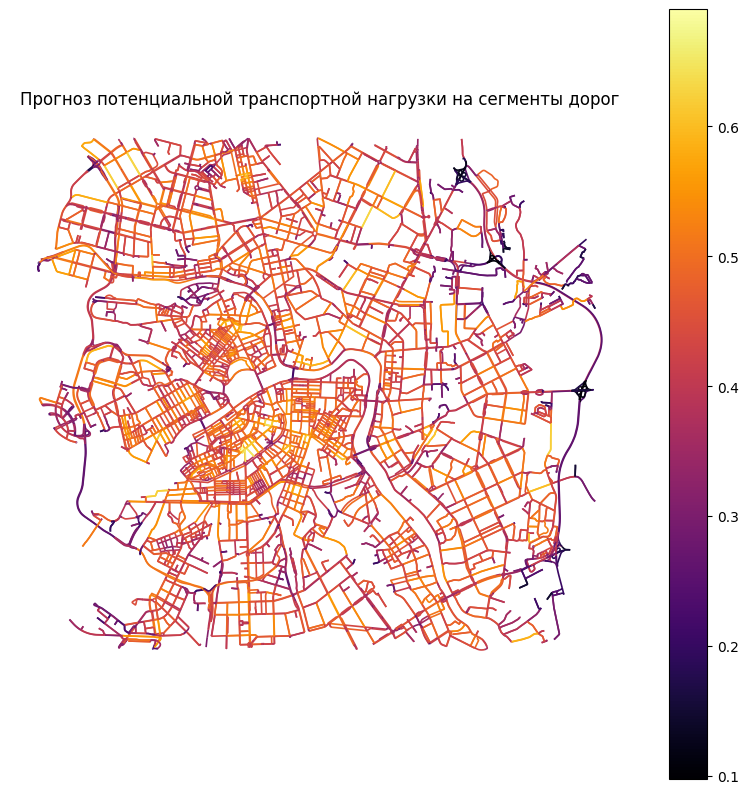

In [ ]:
# Задание 15. Прогноз для всех сегментов + карта.

# Прогноз для всех сегментов
roads["predicted_traffic_load"] = best_model.predict(X)

# Возвращаем геометрию в WGS84
roads_wgs = gpd.GeoDataFrame(roads, geometry="geometry", crs=edges_m.crs).to_crs(4326)

fig, ax = plt.subplots(figsize=(10, 10))
roads_wgs.plot(
    ax=ax,
    column="predicted_traffic_load",
    linewidth=1.2,
    legend=True,
    cmap="inferno"
)
ax.set_title("Прогноз потенциальной транспортной нагрузки на сегменты дорог")
ax.set_axis_off()
plt.show()